<a href="https://colab.research.google.com/github/me1-3/Emsc2010-A3/blob/main/EMSC2010_A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Title:

Dataset used:

- Original -->
  - Name:
  - Source:
- Cleaned -->
  - Name:
  - Source:

Aim: To use Bayes' theorem to determine the posterior probability that the current mean catch rate of the commonwealth fisheries from 2013-2023 is higher than from 2003-2012.

Firstly, we have to define our hypothesis. For this notebook our hypothesis is: The current mean catch rate of the commonwealth fisheries is higher than it has been from 2003-2012.

Baye's theorem was used as its combinations of likelihoods and priors provide a reliable estimate of means and standard deviations.

Then we added our chosen, cleaned dataset to the colab notebook

Notes about how the data set was cleaned:

The data was sorted from lowest to highest for the year column
As the data period we were looking at was 2003-2023, the year 2002 was deleted
The data was sorted from Z-A for the Gear column
As the Gear variable we were looking at was Trawl, all of the others were deleted

In [1]:
#IMPORT REQUIRED LIBRARIES FOR BAYESIAN MODELLING AND PLOTTING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pymc as pm
import arviz as az

In [6]:
#IMPORTING THE SPREADSHEET DATASET INTO THE CODE

spreadsheet_name = 'A3indiv.xlsx'
worksheet_name = 's1'
df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

In [7]:
df.head()

,Datetime_UTC,Datetime_local,Lat_N,Lon_E,Site_description,Depth,Temperature,Salinity,TA,DIC,Nitrate,Ammonium,Ammonium_flag,Phosphate,Silicate,pH
0,2012-06-06T18:44Z,2012-06-07T07:44,-2.818,-171.727,Kanton; Ocean,1.0,28.52,35.42,2342.1,2015.6,3.553,1.232,1.0,0.358,1.702,NaN
1,2012-06-06T18:44Z,2012-06-07T07:44,-2.818,-171.727,Kanton; Ocean,8.0,28.77,35.49,2339.3,2027.0,3.226,0.655,1.0,0.339,1.745,NaN
2,2012-06-06T19:05Z,2012-06-07T08:05,-2.813,-171.720,Kanton; Ocean,1.0,30.22,35.44,2343.3,2020.3,3.426,0.480,1.0,0.259,1.786,NaN
3,2012-06-06T19:15Z,2012-06-07T08:15,-2.812,-171.715,Kanton; Channel,1.0,27.97,35.45,2339.9,2015.1,3.377,0.283,1.0,0.170,1.749,NaN
4,2012-06-06T19:24Z,2012-06-07T08:24,-2.812,-171.715,Kanton; Channel,8.0,29.21,35.45,2344.9,2025.5,3.307,0.155,1.0,0.392,1.718,NaN


In [14]:
#SELECT EARLY YEAR GROUPS FROM THE DATASET
df['Datetime_local'] = pd.to_datetime(df['Datetime_local'])
data_early = df[(df['Datetime_local'].dt.year < 2013)]['Salinity'].dropna()
data_early = data_early[data_early>0]
data_early = np.log10(data_early)

#SELECT RECENT YEAR GROUPS FROM THE DATASET
data_recent = df[(df['Datetime_local'].dt.year >= 2013)]['Salinity'].dropna()
data_recent = data_recent[data_recent>0]
data_recent = np.log10(data_recent)

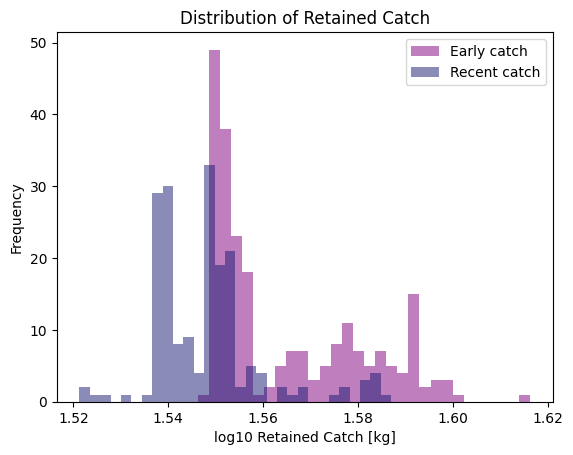

In [15]:
#PLOT HISTOGRAMS TO VISUALISE DISTRIBUTION OF CATCH FOR EACH GROUP
plt.hist(data_early, bins=30, alpha=0.5, color='purple', label='Early (<=2012)')
plt.hist(data_recent, bins=30, alpha=0.5, color='midnightblue', label='Recent (>=2013)')

#LABELS
plt.xlabel("log10 of Ocean Salinity [psu]")
plt.ylabel("Frequency")
plt.title("Distribution of Retained Catch")
plt.legend(["Early catch", "Recent catch"])

#SHOW
plt.show() #show plot